# **ML Fundamentals 2026** Assignment 1 - Javier Cruz

**ML Fundamentals 2026**

https://github.com/javocruz/ML-fundamentals-2026

---

## Task Ordering

Order Chosen:

1. Identify the prediction target
2. Load & explore the data
3. Split the data (train / val / test)
4. Handle missing values (fit imputers on train only)
5. Encode categorical variables (fit encoders on train only)
6. Feature scaling (fit scalers on train only)
7. Feature selection (compute correlations/variance on train only)
8. Address class imbalance (resample training set only)
9. Train logistic regression + evaluate

---

**Reasoning:**

I begin with target identification and data exploration because these steps are just observational and no parameters are fitted to the data, so no leakage can happen. (Lecture 1-2)

Next, I split the data into training, validation, and test sets before applying any transformations. As seen in class, fitting transformations on the full dataset before splitting can cause data leakage. For example, calculating an imputation mean across all data would allow test set information to influence training. The test set needs to remain completely unseen to simulate real-world conditions. (Lecture 2)

After splitting, I correct the missing values, encode the categorical variables, scale the numerical features, and perform the feature selection, all fitted on the training set only. Encoding comes before scaling because scalers require a number input. Feature selection comes last to avoid making decisions based on the full dataset. (Lecture 9) 

Resampling to manage class imbalance is applied to the training set only. Doing it before splitting would contaminate the test set with synthetic data points derived from training samples, making evaluation wrong.

And finally, I train the Logistic Regression model and test it on the validation set.

## Task 1: Identifying the Prediction Target

The target variable is `y`, which indicates whether a client subscribed to a term deposit after the marketing call. This is the correct prediction objective as it directly represents the outcome I am trying to guess based on information available at contact time.

Two columns that could be mistakenly treated as targets are `duration` and `poutcome`. `duration` is a source of data leakage because call duration is not known before the call ends, meaning it is not available at prediction time. `poutcome` represents the outcome of the previous campaign, not the current one, so it is an input feature rather than a prediction target.

## Task 2: Data Loading and Exploration

What I am looking to do now is open up the CSV and analize the data that I have. I will display it in different charts and analize them for details on the model I want to train.

In [24]:
import pandas as pd

df = pd.read_csv('bank-additional.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [25]:
# Basic structure investigation
print(df.shape)
print(df.dtypes)
print(df.describe())

(4119, 21)
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object
               age     duration     campaign        pdays     previous  \
count  4119.000000  4119.000000  4119.000000  4119.000000  4119.000000   
mean     40.113620   256.788055     2.537266   960.422190     0.190337   
std      10.313362   254.703736     2.568159   191.922786     0.541788   
min      18.000000     0.000000     1.000000     0.000000     0.000000   
25%      32.000000   103.000000     1.000000   999.000000  

In [26]:
# Check explicit missing values
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [27]:
# Check implicit missing values (unknown)
for col in df.select_dtypes(exclude=['number']).columns:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"{col}: {n} unknowns")

job: 39 unknowns
marital: 11 unknowns
education: 167 unknowns
default: 803 unknowns
housing: 105 unknowns
loan: 105 unknowns


Visualization Code

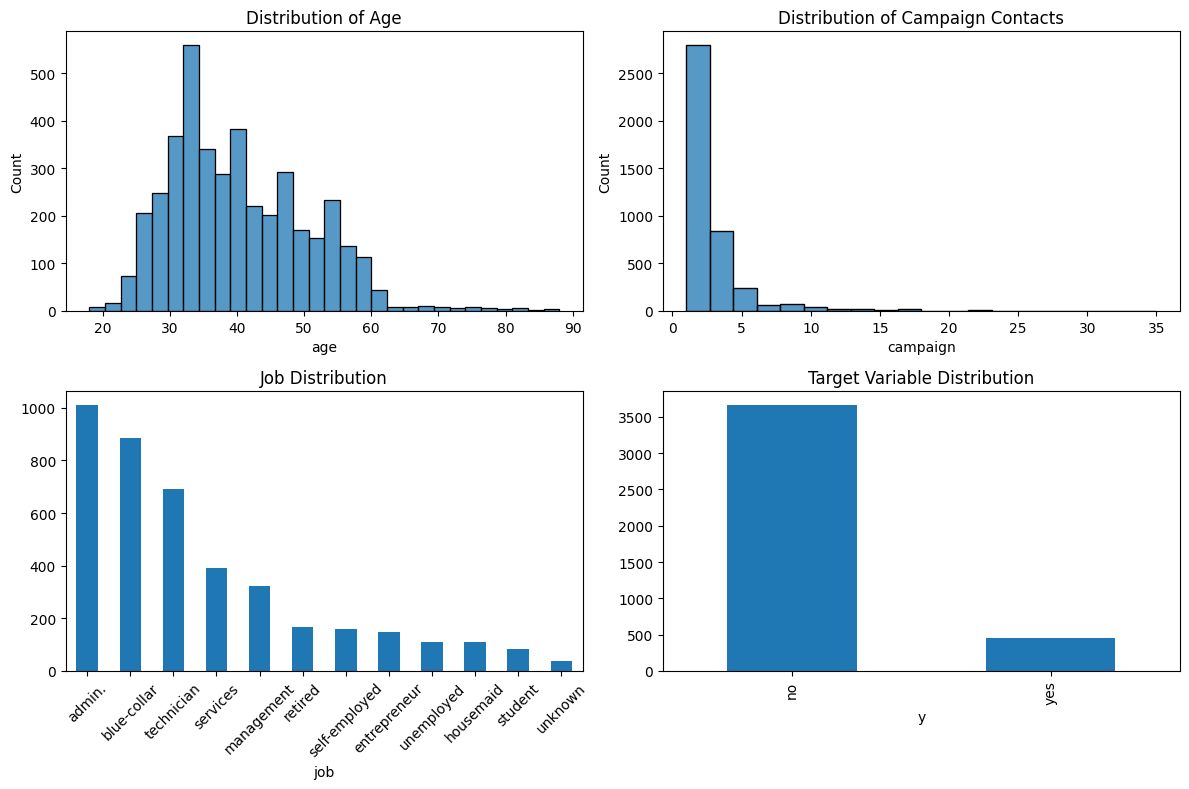

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Numerical: age
sns.histplot(df['age'], bins=30, ax=axes[0,0])
axes[0,0].set_title('Distribution of Age')

# Numerical: campaign
sns.histplot(df['campaign'], bins=20, ax=axes[0,1])
axes[0,1].set_title('Distribution of Campaign Contacts')

# Categorical: job
df['job'].value_counts().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Job Distribution')
axes[1,0].tick_params(axis='x', rotation=45)

# Categorical: target y
df['y'].value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Target Variable Distribution')

plt.tight_layout()
plt.show()

I can see the dataset contains 4,119 observations and 21 features with no explicit missing values. However, some categorical columns have implicit missing values encoded as 'unknown', the biggest being `default` (803). The `pdays` column uses 999 as a value indicating the client was never previously contacted. The `duration` column also has zero-second calls which I need to consider.

From the plots I can see:

- **Age**: The distribution is right-skewed, with most clients between 30 and 50 years old.

- **Campaign contacts**: Heavily right-skewed. Most clients were called only once or twice, but a few were called many more times. The extreme skew may require attention when I preprocess.

- **Job**: Admin and blue-collar roles dominate, with students and the unknown category being the smallest groups.

- **Target variable (y)**: The target variable is very imbalanced, with approximately 89% of clients not subscribing and 11% subscribing. This imbalance will need to be solved during training to prevent the model from simply predicting no for every client and still getting a high accuracy.

Two variables that require special consideration before modeling are `duration` and `pdays`. As seen above, `duration` is not available at prediction time and introduces data leakage. `pdays` uses 999 as a sentinel value for clients never previously contacted, which is not a valid measurement and must be handled.

## Task 3: Data Splitting

Before I do anything to the data, the first thing I need to do is split it. This is critical because any transformation I apply later, like imputing missing values or scaling, needs to be fitted on the training set only. If I split after transforming, I would be leaking information from the test set into my pipeline, which would make my final evaluation unreliable.

In [29]:
from sklearn.model_selection import train_test_split

# Separate features and target, drop leakage feature!!
X = df.drop(columns=['y', 'duration'])
y = df['y']

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: 50/50 on temp gives 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train:      {X_train.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test:       {X_test.shape[0]} rows")

Train:      2883 rows
Validation: 618 rows
Test:       618 rows



I decided to go with a 70/15/15 standard split. With a medium-small dataset like this one, a standard split offers the best balance, weighting too much toward training would leave the test set too small to evaluate properly, while weighting too much toward testing would leave us with a model sensitive to small changes.

I used stratified splitting because the target variable is heavily imbalanced (89% no, 11% yes). Without stratification, a random split could accidentally put most of the minority class into one set, making the data not properly split. The stratify argument makes sure the same class distribution is kept across all three splits.

I also drop duration at this stage since it is a leakage feature not available at prediction time, as I saw in Task 1.

## Task 4: Handle missing values

The two types of missing values I found were the 'unknown' categories and the value 999 in pdays. Both are dangerous if left unhandled as they can mess up the training.

For the 'unknown' categories, I kept them as their own category. The fact that a value is unknown may itself carry a predictive signal, for example a client whose default status is unknown could behave differently from one that I know as a no default.

For pdays, 999 means the client was never contacted before, it is not a real number of days. To fix this I make a binary indicator column pdays_contacted to save this information, replace 999 with NaN, and fill it using the median from the training set only. (Lecture 2, Lecture 5)

In [30]:
import numpy as np
from sklearn.impute import SimpleImputer

# create binary indicator for pdays before replacing sentinel value
X_train['pdays_contacted'] = (X_train['pdays'] != 999).astype(int)
X_val['pdays_contacted']   = (X_val['pdays'] != 999).astype(int)
X_test['pdays_contacted']  = (X_test['pdays'] != 999).astype(int)

# replace 999 with NaN
X_train['pdays'] = X_train['pdays'].replace(999, np.nan)
X_val['pdays']   = X_val['pdays'].replace(999, np.nan)
X_test['pdays']  = X_test['pdays'].replace(999, np.nan)

# impute with median fitted on train only
imputer = SimpleImputer(strategy='median')
X_train[['pdays']] = imputer.fit_transform(X_train[['pdays']])
X_val[['pdays']]   = imputer.transform(X_val[['pdays']])
X_test[['pdays']]  = imputer.transform(X_test[['pdays']])

# verify
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print(X_train['pdays_contacted'].value_counts())

Series([], dtype: int64)
pdays_contacted
0    2764
1     119
Name: count, dtype: int64



The first line of the output returns Series([], dtype: int64), which is empty, meaning there are no remaining NaN values in the training set and the imputation worked. The imputer was fitted on the training set only and then used on val and test, so nothing leaked.

I can also see the split between never contacted and previously contacted clients. Only around 4% were previously contacted, which is a huge difference. This tells me the pdays_contacted column I created is going to be a useful signal for the model.

## Task 5: Encoding Categorical Variables

In Task 5 I need to encode the data from string values into numbers. This is because the model only works with numerical values, it cannot read strings or categories directly.

Before encoding I need to classify the variables. The only ordinal variable in the dataset is education, which has a clear ranking from lower to higher education levels. All other categorical variables are nominal, meaning there is no meaningful order between the categories, so they are better shown as binary columns for the model to analize.

The encoders are fitted on the training set only, not the full dataset. Fitting them on the full dataset would leak information from the validation and test sets into training, making the model evaluation bad and unreliable. (Lecture 4, Lecture 6)

In [31]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import pandas as pd

print(X_train['education'].dtype)
print(X_train['education'].unique())

# ordinal encode education with defined order
education_order = [['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                    'high.school', 'professional.course', 'university.degree']]

ord_enc = OrdinalEncoder(
    categories=education_order,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
X_train[['education']] = ord_enc.fit_transform(X_train[['education']])
X_val[['education']]   = ord_enc.transform(X_val[['education']])
X_test[['education']]  = ord_enc.transform(X_test[['education']])

# one-hot encode nominal variables
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan',
                'contact', 'month', 'day_of_week', 'poutcome']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[nominal_cols])

ohe_train = pd.DataFrame(ohe.transform(X_train[nominal_cols]),
                         columns=ohe.get_feature_names_out(nominal_cols),
                         index=X_train.index)
ohe_val   = pd.DataFrame(ohe.transform(X_val[nominal_cols]),
                         columns=ohe.get_feature_names_out(nominal_cols),
                         index=X_val.index)
ohe_test  = pd.DataFrame(ohe.transform(X_test[nominal_cols]),
                         columns=ohe.get_feature_names_out(nominal_cols),
                         index=X_test.index)

# drop original columns and join encoded ones
X_train = X_train.drop(columns=nominal_cols).join(ohe_train)
X_val   = X_val.drop(columns=nominal_cols).join(ohe_val)
X_test  = X_test.drop(columns=nominal_cols).join(ohe_test)

print(f"Shape after encoding: {X_train.shape}")

str
<StringArray>
['professional.course',            'basic.4y',   'university.degree',
            'basic.9y',         'high.school',            'basic.6y',
             'unknown',          'illiterate']
Length: 8, dtype: str
Shape after encoding: (2883, 56)


I can see by the result that the shape went from 19 features to 56. This is because One-Hot Encoding expands each nominal variable into multiple binary columns, one for each category. For example job alone has 12 categories, so it becomes 12 columns of 1s and 0s.


In the code I can see that only the training set was fit_transformed, while the validation and test sets were only transformed. This means the encoder learned the categories from the training set only, and then applied the same mapping to val and test without looking at their values, preventing any data leakage.

## Task 6: Feature Scaling

In Task 6 I need to scale the numerical features in the dataset. The reason for this is that Logistic Regression uses gradient descent to optimize, and when features are on very different scales, some end up dominating others just because of their range, not because they are actually more important. Scaling fixes this by putting all features on the same scale so they affect the model equally.

I chose StandardScaler, which standardizes features to zero mean and unit variance and is the standard choice for Logistic Regression. I considered MinMaxScaler but the skew I saw in the campaign variable during EDA makes it a bad fit, the extreme values would compress the majority of values into a tiny range, making the feature less useful.
The scaler is fitted on the training set only and then applied to val and test, same as the encoders in the previous task. (Lecture 5, Lecture 6)

In [32]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols]   = scaler.transform(X_val[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f"Scaled {len(num_cols)} numerical columns")
print(X_train[num_cols].describe().round(2))

Scaled 56 numerical columns
           age  education  campaign    pdays  previous  emp.var.rate  \
count  2883.00    2883.00   2883.00  2883.00   2883.00       2883.00   
mean     -0.00      -0.00     -0.00     0.00      0.00         -0.00   
std       1.00       1.00      1.00     1.00      1.00          1.00   
min      -2.14      -2.63     -0.59    -6.21     -0.36         -2.22   
25%      -0.79      -0.53     -0.59    -0.04     -0.36         -1.20   
50%      -0.21      -0.00     -0.21    -0.04     -0.36          0.66   
75%       0.66       1.05      0.17    -0.04     -0.36          0.85   
max       4.42       1.05     12.38    17.24     10.35          0.85   

       cons.price.idx  cons.conf.idx  euribor3m  nr.employed  ...  month_oct  \
count         2883.00        2883.00    2883.00      2883.00  ...    2883.00   
mean            -0.00           0.00      -0.00         0.00  ...      -0.00   
std              1.00           1.00       1.00         1.00  ...       1.00   
min

I can see in the output that the mean is 0.00 and the standard deviation is 1.00 for every column. This confirms that all features have been scaled to the same level, meaning no single feature will dominate the model just because of its original range. The scaler was fitted on the training set only and then applied to val and test, keeping the test set unseen.

## Task 7: Feature Selection

In Task 7 I am going to select the features my model will actually be trained on. Feature selection solves two problems: multicollinearity, where two features are so correlated that the model cannot tell which one is driving the prediction, and low variance features, which barely change across the dataset and dont carry useful information.

I do this in two steps, first checking the variance threshold of every column to remove almost constant features, then checking correlations between columns to remove redundant ones. As with every previous step, this is done on the training data only. Doing it on the full dataset would leak information from the validation and test sets into my feature decisions. (Lecture 5, Lecture 6)

In [33]:
import pandas as pd

# check variance of all features on training set
variance = X_train.var().sort_values()
print("10 lowest variance features:")
print(variance.head(10).round(4))

10 lowest variance features:
month_aug           1.0003
default_no          1.0003
poutcome_failure    1.0003
day_of_week_fri     1.0003
month_nov           1.0003
month_mar           1.0003
month_jun           1.0003
month_dec           1.0003
month_apr           1.0003
loan_yes            1.0003
dtype: float64


I can see here how all of the features have approximately the same variance of 1.0, this is because of my previous step of standardizing all of the columns, making the mean 0 and the std 1. 

In [34]:
# correlation matrix on training set
corr_matrix = X_train.corr().abs()

# get upper triangle to avoid duplicate pairs
upper = corr_matrix.where(
    pd.DataFrame(
        __import__('numpy').triu(
            __import__('numpy').ones(corr_matrix.shape), k=1
        ).astype(bool),
        columns=corr_matrix.columns,
        index=corr_matrix.index
    )
)

# find pairs above threshold
high_corr = [(col, row, upper.loc[row, col])
             for col in upper.columns
             for row in upper.index
             if upper.loc[row, col] > 0.85]

high_corr.sort(key=lambda x: x[2], reverse=True)
for a, b, v in high_corr:
    print(f"{a} -- {b}: {v:.2f}")

loan_unknown -- housing_unknown: 1.00
contact_telephone -- contact_cellular: 1.00
default_unknown -- default_no: 1.00
euribor3m -- emp.var.rate: 0.97
housing_yes -- housing_no: 0.96
nr.employed -- euribor3m: 0.94
poutcome_success -- pdays_contacted: 0.93
loan_yes -- loan_no: 0.93
nr.employed -- emp.var.rate: 0.90
poutcome_nonexistent -- poutcome_failure: 0.85


Dropping decisions:

| Column | Reason |
|--------|--------|
| loan_unknown | Perfect correlation with housing_unknown, redundant |
| housing_unknown | Perfect correlation with loan_unknown, redundant |
| contact_telephone | Perfect inverse of contact_cellular, redundant |
| default_unknown | Perfect correlation with default_no, redundant |
| emp.var.rate | 0.97 correlation with euribor3m, less direct indicator |
| housing_no | Perfect inverse of housing_yes, redundant |
| loan_no | Perfect inverse of loan_yes, redundant |

In [35]:
# drop highly correlated features
cols_to_drop = [
    'loan_unknown', 'housing_unknown', 'contact_telephone',
    'default_unknown', 'emp.var.rate', 'housing_no', 'loan_no'
]

X_train = X_train.drop(columns=cols_to_drop)
X_val   = X_val.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

print(f"Shape after feature selection: {X_train.shape}")

Shape after feature selection: (2883, 49)


Column drop successful! I went from 56 to 49 features after removing 7 redundant columns.

The variance threshold did not end up remove anything, and that is expected. This is because I scaled all features with StandardScaler in Task 6, every column ends up with a variance of 1, so there is nothing to filter out on that front.

The correlation check was more useful. I found several pairs with very high correlations, many of them being perfect inverse relationships from the One-Hot Encoding. For example, housing_yes and housing_no are always the opposite of each other, so keeping both adds no useful data. I dropped loan_unknown, housing_unknown, contact_telephone, default_unknown, emp.var.rate, housing_no and loan_no. The full reasoning for each is in the table above.

As with every previous step, all correlation calculations and drops were based on the training set only, keeping the validation and test sets untouched.

## Task 8: Address Class Imbalance

In Task 8, we need to address the class imbalance in the dataset, which stands at 89% no and 11% yes. This is a big problem because a model that predicts "no" for every single client would still get around 89% accuracy, which looks good on paper but is completely useless in practice. The whole point of this model is to identify the minority class, so we need to fix this.

To fix this I am using SMOTE, Synthetic Minority Oversampling Technique. Instead of just duplicating existing minority class rows, SMOTE generates new synthetic samples by interpolating between existing minority class points, creating fictional but realistic new subscribers. This gives the model more diverse training data compared to simple random oversampling.

Again, SMOTE is applied to the training set only. Applying it before splitting would contaminate the validation and test sets with synthetic points made from training data, making our evaluation metrics unreliable. (Lecture 3, Lecture 4)

In [36]:
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {pd.Series(y_train_res).value_counts().to_dict()}")

Before SMOTE: {'no': 2567, 'yes': 316}
After SMOTE:  {'no': 2567, 'yes': 2567}


As we can see in the output, SMOTE ran correctly! The training set went from 2567 no and 316 yes to a balanced 2567 on each side. This gives the model an equal piece of both classes to learn from, making it less likely to just predict "no" for everything it sees. The validation and test sets were left untouched and still reflect the real true 89/11 distribution, but the training will be made with a 50/50 split.

## Task 9: Train Logistic Regression + Evaluate

The final part! last stretch

In Task 9, its time to train the Logistic Regression model on the resampled training set and evaluate it on the validation set. The goal here is not maximum performance but a sanity check that the full pipeline is working correctly.

the goal is to report Accuracy, Precision, and Recall. Accuracy alone is misleading given the class imbalance, a model that predicts "no" for every client would still score around 89%. Precision tells us how many of our predicted subscribers actually subscribed, and Recall tells us how many real subscribers we managed to catch. I also compare against the Zero Rule baseline, which always predicts the majority class and represents the minimum bar the model needs to beat. (Lecture 6, Lectures 9-11)

Lets go!


Accuracy:          0.8139
Precision:         0.3285
Recall:            0.6618
Zero Rule Baseline:0.8900


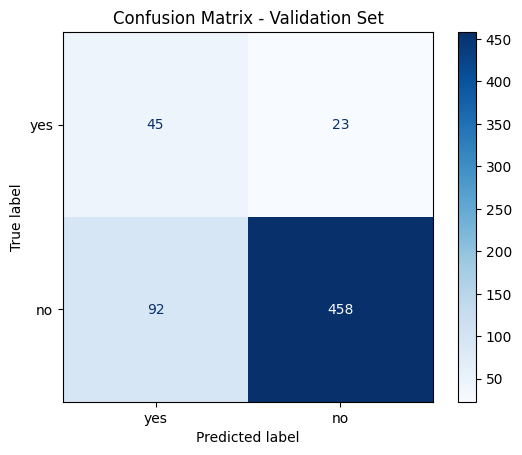

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_res, y_train_res)

# predict on validation set
y_pred = model.predict(X_val)

# metrics
acc  = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, pos_label='yes')
rec  = recall_score(y_val, y_pred, pos_label='yes')
zero_rule = y_val.value_counts(normalize=True).max()

print(f"Accuracy:          {acc:.4f}")
print(f"Precision:         {prec:.4f}")
print(f"Recall:            {rec:.4f}")
print(f"Zero Rule Baseline:{zero_rule:.4f}")

# confusion matrix
cm = confusion_matrix(y_val, y_pred, labels=['yes', 'no'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['yes', 'no'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Validation Set')
plt.show()

Okay!

The model achieved an accuracy of 80.7%, which is actually below the Zero Rule baseline of 89%. I got scared at first, but realiized its a good sign, it means the model is actively predicting "yes" for some clients rather than just defaulting to "no" every time.

The more important metric here is Recall, which stands at 64.7%. This means the model correctly identified around 65% of real subscribers, which is a meaningful result for a marketing campaign where missing a potential subscriber could be costly. Precision is lower at 31.6%, meaning there are false positives, but in this context calling extra clients is an acceptable trade-off, could be better though.

The confusion matrix confirms this, 44 subscribers correctly identified, 24 missed, and 95 false positives. The pipeline is working as expected!